Shape: (7050, 16)

Missing values:
 status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64


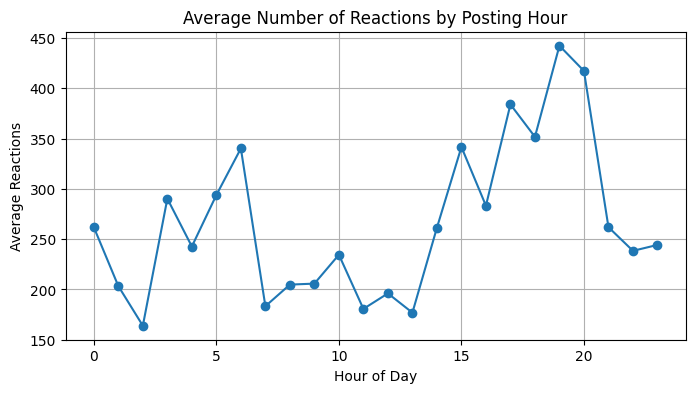

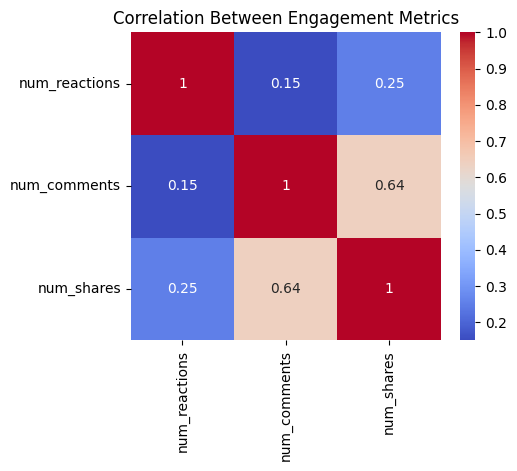

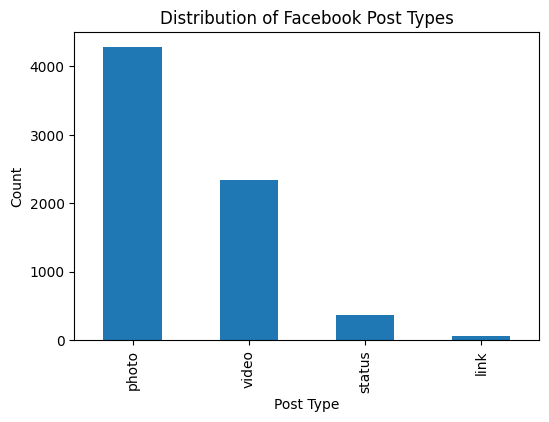


Average engagement by post type:

             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


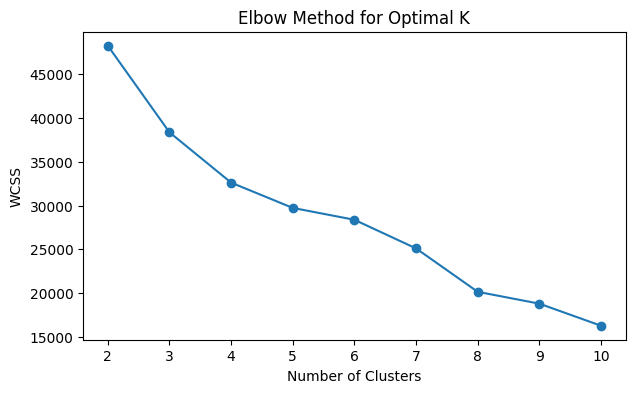


Cluster counts:
 cluster
0    6405
2     372
1     273
Name: count, dtype: int64

Cluster profiling:

         num_reactions  num_comments  num_shares    num_likes   num_loves  \
cluster                                                                     
0           113.854489    106.228571   21.711319   105.294770    7.464637   
1           786.871795   3217.948718  508.300366   606.293040  149.344322   
2          1823.311828     61.333333   11.645161  1817.534946    3.104839   

          num_wows  num_hahas  num_sads  num_angrys  
cluster                                              
0         0.549727   0.339578  0.148790    0.054020  
1        17.080586   9.747253  2.758242    1.648352  
2         2.435484   0.198925  0.032258    0.005376  


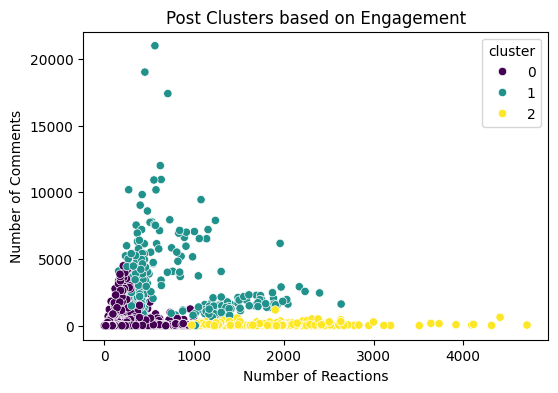


Silhouette Score: 0.7499921477392748


In [7]:
# ================================
# Facebook Live Sellers - KMeans
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ----------------
# Load Dataset
# ----------------
df = pd.read_csv('/content/drive/MyDrive/ML_Project/Facebook_Marketplace_data.csv')


# ----------------
# Basic Info
# ----------------
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

# ----------------
# Time of Upload vs Reactions
# ----------------
df['status_published'] = pd.to_datetime(df['status_published'])
df['hour'] = df['status_published'].dt.hour

hourly_reactions = df.groupby('hour')['num_reactions'].mean()

plt.figure(figsize=(8,4))
hourly_reactions.plot(marker='o')
plt.title('Average Number of Reactions by Posting Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Reactions')
plt.grid()
plt.show()

# ----------------
# Correlation Analysis
# ----------------
corr = df[['num_reactions','num_comments','num_shares']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Between Engagement Metrics')
plt.show()

# ----------------
# Post Type Distribution
# ----------------
plt.figure(figsize=(6,4))
df['status_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Facebook Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

# ----------------
# Average Engagement per Post Type
# ----------------
print("\nAverage engagement by post type:\n")
print(df.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean())

# ----------------
# K-Means Feature Selection
# ----------------
features = df[['num_reactions', 'num_comments', 'num_shares',
               'num_likes', 'num_loves', 'num_wows',
               'num_hahas', 'num_sads', 'num_angrys']]

# ----------------
# Feature Scaling
# ----------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# ----------------
# Elbow Method
# ----------------
wcss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# ----------------
# Apply K-Means (K=3)
# ----------------
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print("\nCluster counts:\n", df['cluster'].value_counts())

# ----------------
# Cluster Profiling
# ----------------
print("\nCluster profiling:\n")
print(df.groupby('cluster')[features.columns].mean())

# ----------------
# Cluster Visualization
# ----------------
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['num_reactions'],
    y=df['num_comments'],
    hue=df['cluster'],
    palette='viridis'
)
plt.title('Post Clusters based on Engagement')
plt.xlabel('Number of Reactions')
plt.ylabel('Number of Comments')
plt.show()

# ----------------
# Silhouette Score (Optional)
# ----------------
score = silhouette_score(scaled_features, df['cluster'])
print("\nSilhouette Score:", score)


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
os.listdir('/content/drive/My Drive/ML_Project')


['Facebook_Marketplace_data.csv']